<a href="https://colab.research.google.com/github/Mehtabul-Islam/Mushroom-Classification-Using-Machine-Learning/blob/main/Machine%20Trained%20Project%20Model/Mushroom_Classification_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE422 Lab Project


### **Course:** CSE422 – Artificial Intelligence

## **Lab Project: Mushroom Classification Using Machine Learning**

Submitted By:

> 24301400 - Md. Mehtabul Islam


> 24301402 - Hossain Ismoth Zeanin





**Section:** 18

 ***Department of Computer Science and Engineering
BRAC University***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Dataset Description**

## Dataset Description

In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mushroom_dataset.csv', sep=';')
df.head(10)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w




> **Features**



In [3]:
print("Features:")
rows, columns = df.shape
print("Records:", rows)
print("Total columns:", columns)
print(df.columns.tolist())

X = df.drop('class', axis=1)
y = df['class']
print("Number of input features:", X.shape[1])
print("Target:", y.name)

Features:
Records: 61069
Total columns: 21
['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']
Number of input features: 20
Target: class




> **Problem Type**



In [4]:
print(df['class'].unique())
print("Number of classes:", df['class'].nunique())

['p' 'e']
Number of classes: 2


This project is a classification problem because the target variable class consists of categorical values. The goal is to classify each mushroom into its appropriate class based on its physical characteristics.



> **Data points**



In [5]:
print("Number of data points:", df.shape[0])

Number of data points: 61069


The dataset contains 61,069 data points (records).



> **Feature Type**



In [6]:
print(df.dtypes)

class                    object
cap-diameter            float64
cap-shape                object
cap-surface              object
cap-color                object
does-bruise-or-bleed     object
gill-attachment          object
gill-spacing             object
gill-color               object
stem-height             float64
stem-width              float64
stem-root                object
stem-surface             object
stem-color               object
veil-type                object
veil-color               object
has-ring                 object
ring-type                object
spore-print-color        object
habitat                  object
season                   object
dtype: object


In [7]:
categorical = df.select_dtypes(include='object').columns
quantitative = df.select_dtypes(include=['int64', 'float64']).columns

print("\nCategorical features:", len(categorical))
print("Categorical:", list(categorical))

print("\nQuantitative features:", len(quantitative))
print("Quantitative:", list(quantitative))


Categorical features: 18
Categorical: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']

Quantitative features: 3
Quantitative: ['cap-diameter', 'stem-height', 'stem-width']


The dataset contains both categorical and quantitative features. The categorical features describe characteristics such as cap shape, cap color, gill color, and habitat, while the quantitative features include measurements such as cap diameter, stem height, and stem width.


> **Do we need to encode the categorical variables?**



Yes, the categorical variables need to be encoded because most machine learning algorithms require numerical input. One-Hot Encoding will be used to convert categorical variables into numerical values while preserving the distinction between different categories.



> **Correlation of all the features (input and output features) (Applying heatmap
using the seaborn library)**



In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

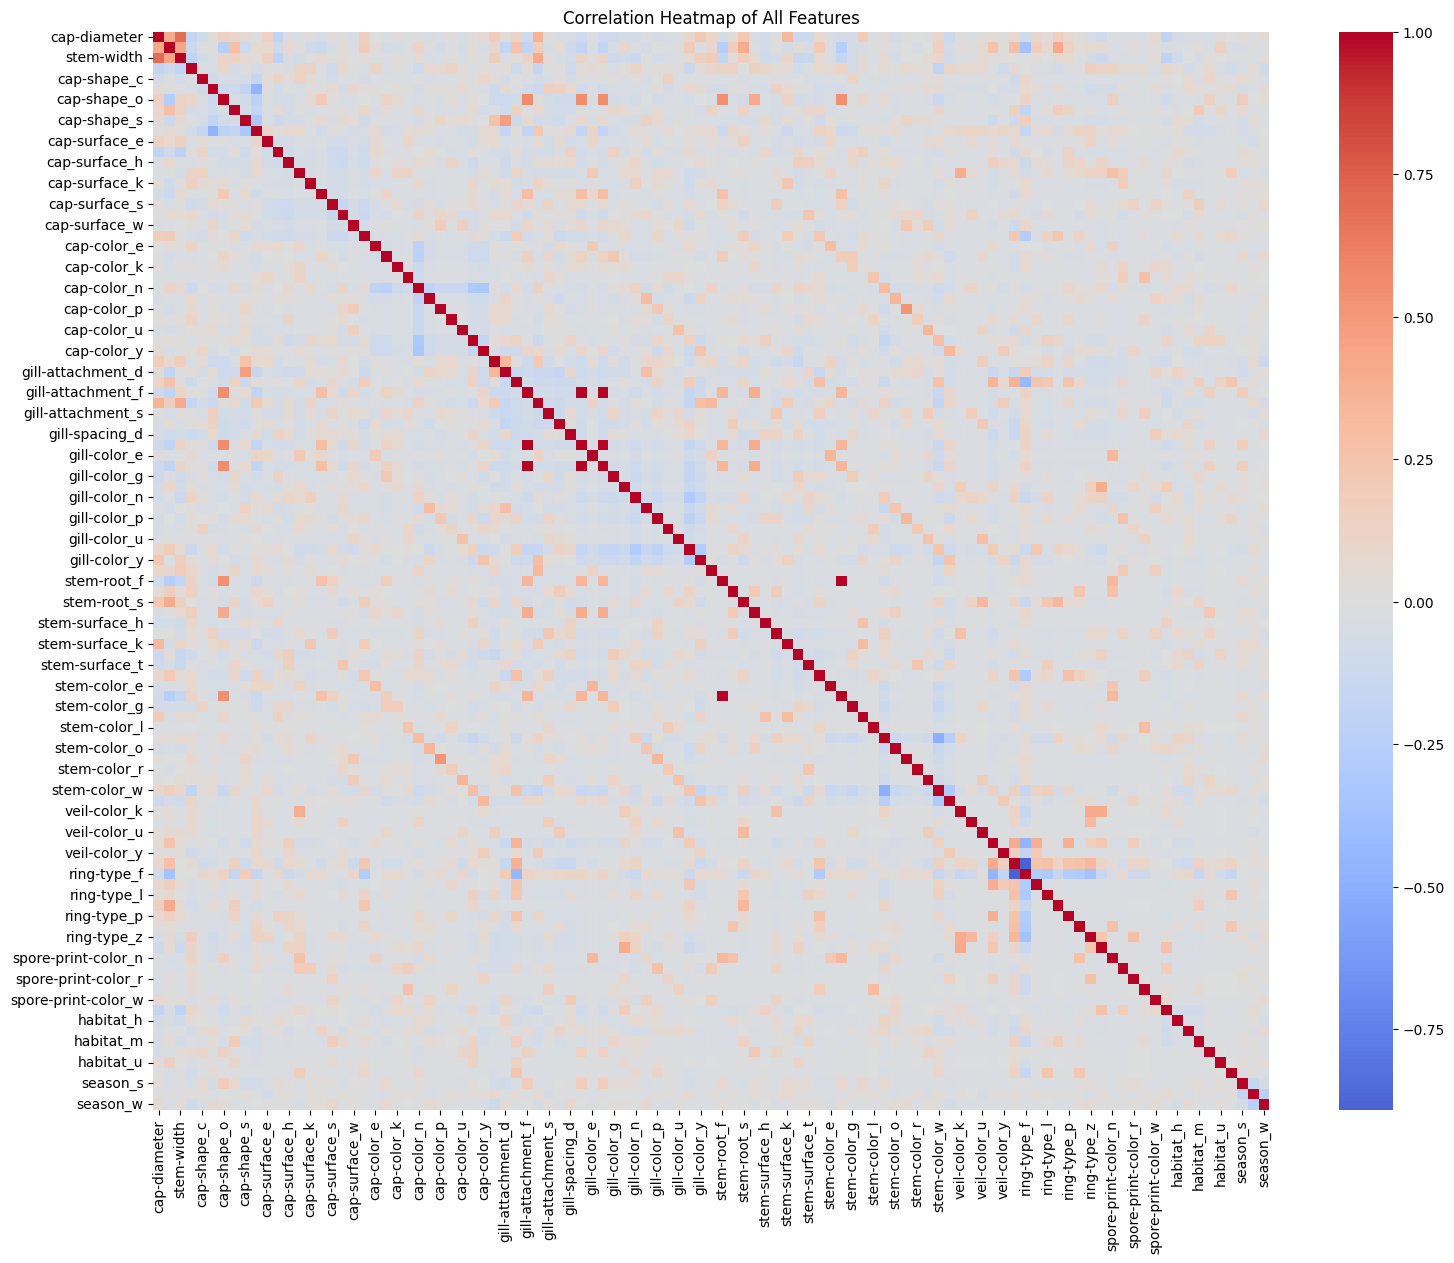

In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)
correlation = df_encoded.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(correlation, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of All Features")
plt.show()

A correlation heatmap was generated using the Seaborn library to examine the relationships between the input features and the target variable. Since the dataset contains categorical variables, they were first converted into numerical values using one-hot encoding. The heatmap helps identify features that have stronger or weaker correlations with each other and with the target variable.



> **Understanding after the correlation test**



From the correlation heatmap, we can observe that some features have stronger relationships with each other, while others have relatively weak correlations. The correlation values also help identify which features may have a stronger relationship with the target variable. Since most of the features are categorical, the correlations should be interpreted carefully. The heatmap provides an overview of the relationships among the encoded features and helps in understanding the structure of the dataset before model training.

## Imbalanced Dataset

In [10]:
class_counts = df['class'].value_counts()
print(class_counts)

print("Class distribution (%):")
print(df['class'].value_counts(normalize=True) * 100)

class
p    33888
e    27181
Name: count, dtype: int64
Class distribution (%):
class
p    55.491329
e    44.508671
Name: proportion, dtype: float64


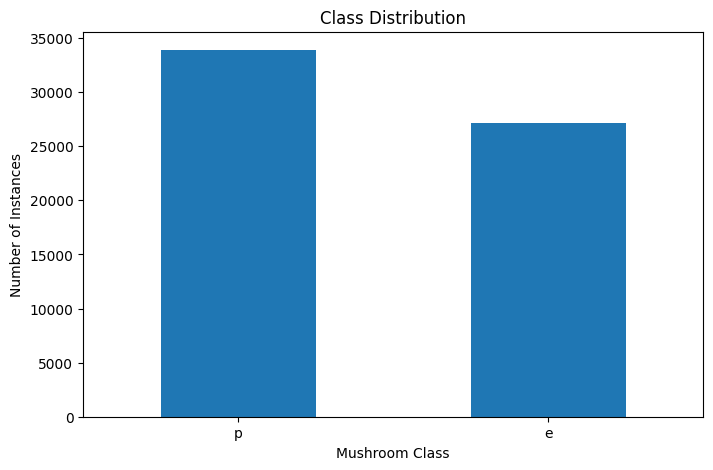

In [11]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar')

plt.title('Class Distribution')
plt.xlabel('Mushroom Class')
plt.ylabel('Number of Instances')
plt.xticks(rotation=0)
plt.show()

The class distribution was analyzed using a bar chart. The number of instances is not exactly equal among all classes, indicating that the dataset is imbalanced. This imbalance should be considered during model training and evaluation because a model may favor the majority class. Therefore, metrics such as precision, recall, F1-score, and the confusion matrix will also be considered along with accuracy.



## Exploratory data analysis



### **Descriptive Analysis**



> 1. Separate Numerical and Categorical Features



In [12]:
numerical_data = df.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} numerical features:')
print(numerical_features)

categorical_data = df.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()
print(f'\nThere are {len(categorical_features)} categorical features:')
print(categorical_features)

There are 3 numerical features:
['cap-diameter', 'stem-height', 'stem-width']

There are 18 categorical features:
['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']




> 2. Descriptive Analysis - Summary Statistics of Numerical Features



In [13]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
cap-diameter,61069.0,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34
stem-height,61069.0,6.581538,3.370017,0.00,4.64,5.95,7.74,33.92
stem-width,61069.0,12.149410,10.035955,0.00,5.21,10.19,16.57,103.91


The descriptive analysis provides statistical information about the numerical features. The features have different ranges and distributions, indicating that feature scaling may be necessary for distance-based models such as KNN and Neural Networks.



> 3. Descriptive Analysis - Summary Statistics of Categorical Features



In [14]:
categorical_data.describe().T

,count,unique,top,freq
class,61069,2,p,33888
cap-shape,61069,7,x,26934
cap-surface,46949,11,t,8196
cap-color,61069,12,n,24218
does-bruise-or-bleed,61069,2,f,50479
gill-attachment,51185,7,a,12698
gill-spacing,36006,3,c,24710
gill-color,61069,12,w,18521
stem-root,9531,5,s,3177
stem-surface,22945,8,s,6025




> 4. Variance of Numerical Features



In [15]:
numerical_data.var()

,0
cap-diameter,27.718592
stem-height,11.357014
stem-width,100.720394




> 5. Skewness of Numerical Features



In [16]:
numerical_data.skew()

,0
cap-diameter,3.822844
stem-height,2.020904
stem-width,2.164957


Skewness analysis was performed to understand the distribution of numerical features. The results indicate whether the features are symmetrically distributed or skewed. Highly skewed features may require further preprocessing or transformation depending on the model requirements.



> 6. Histograms



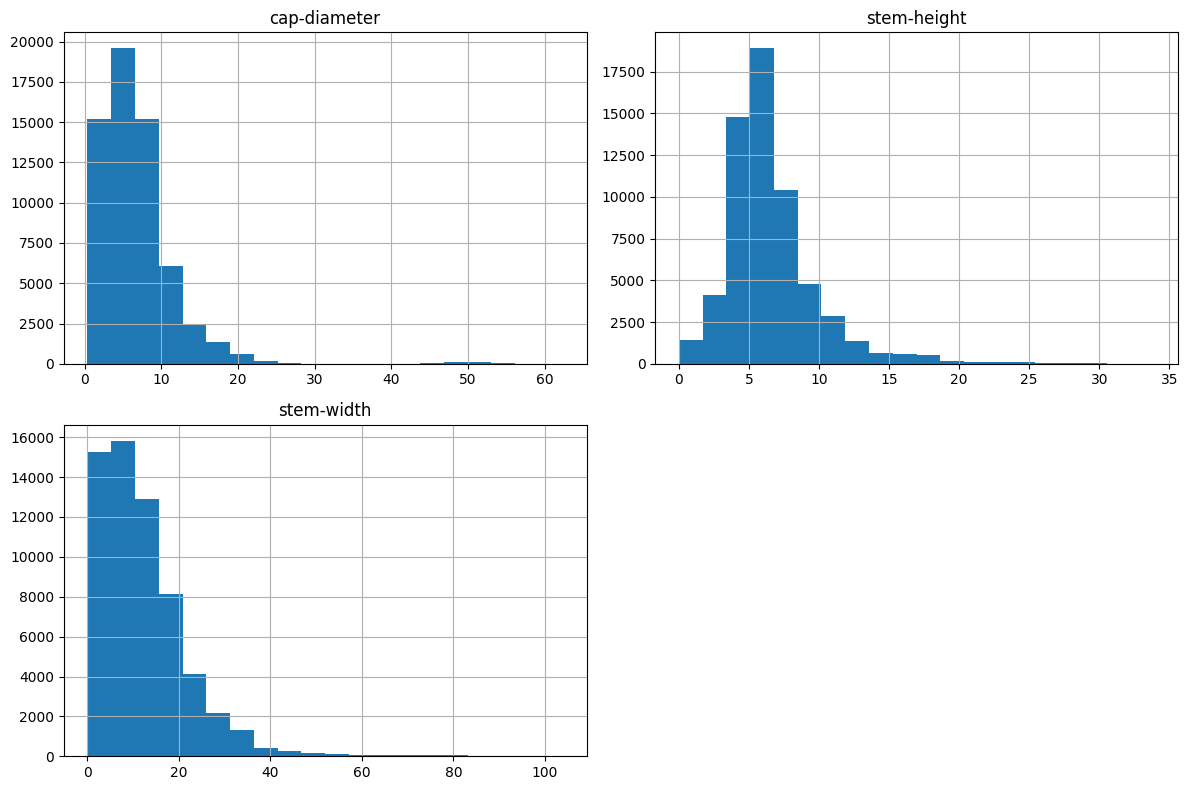

In [17]:
numerical_data.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()



> 7. Boxplots



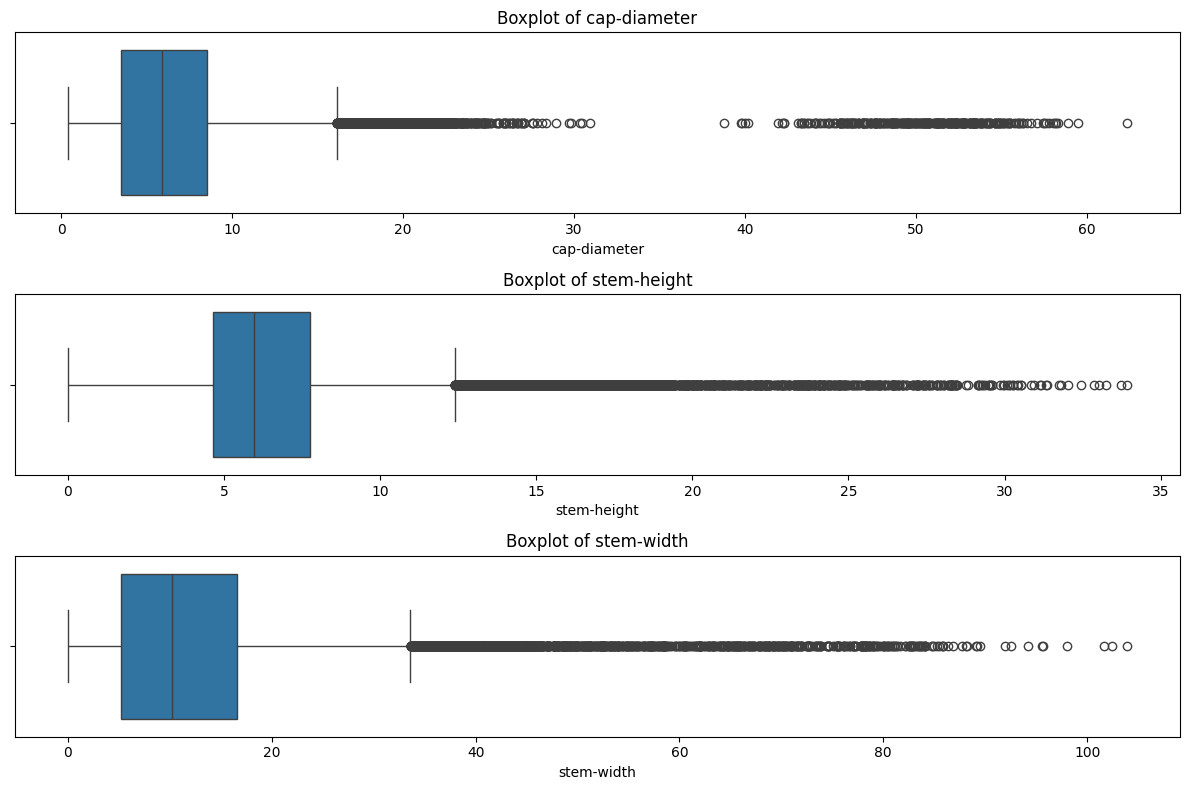

In [18]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

Boxplots were generated for the numerical features to identify potential outliers and understand their distributions. Any extreme values observed in the plots can be further investigated before model training.



> 8. Number of Unique Values - Numerical Features



In [19]:
numerical_data.nunique()

,0
cap-diameter,2571
stem-height,2226
stem-width,4630




> 9. Number of Unique Values - Categorical Features



In [20]:
unique_counts = categorical_data.nunique()
print(unique_counts)

class                    2
cap-shape                7
cap-surface             11
cap-color               12
does-bruise-or-bleed     2
gill-attachment          7
gill-spacing             3
gill-color              12
stem-root                5
stem-surface             8
stem-color              13
veil-type                1
veil-color               6
has-ring                 2
ring-type                8
spore-print-color        7
habitat                  8
season                   4
dtype: int64


The number of unique values varies significantly among categorical features. Features with multiple categories require appropriate categorical encoding before being used for machine learning.



> 10. Missing Values



In [21]:
df.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0




> 11. Distribution of Categorical Features



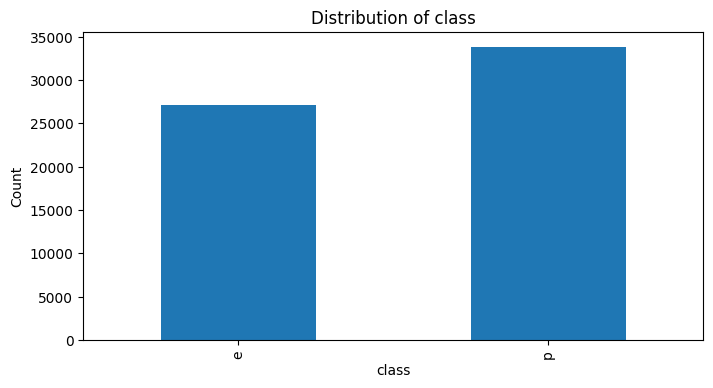

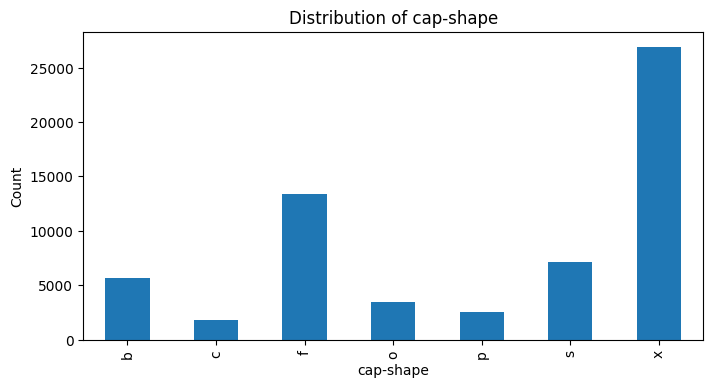

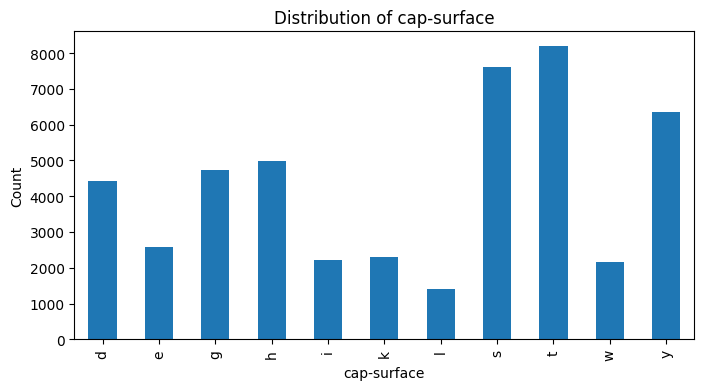

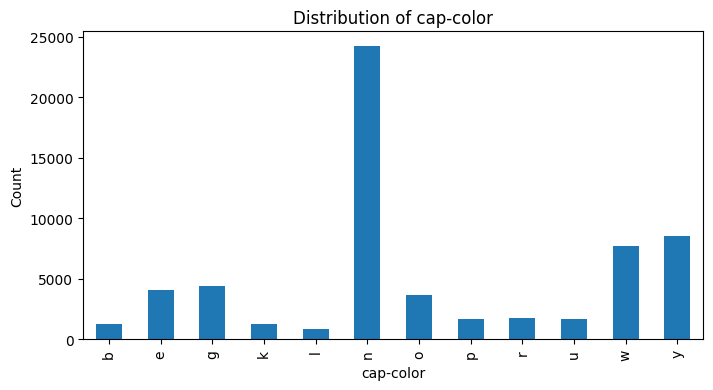

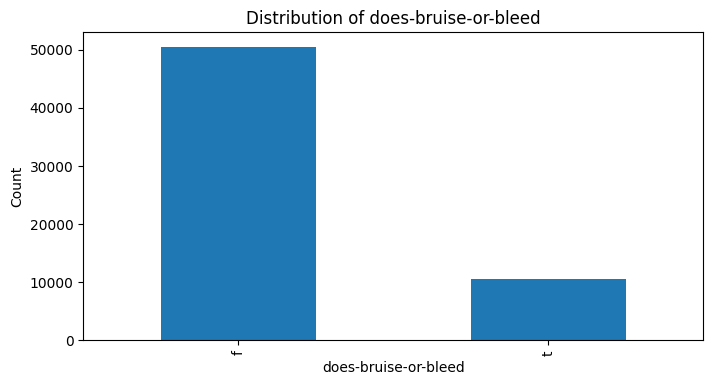

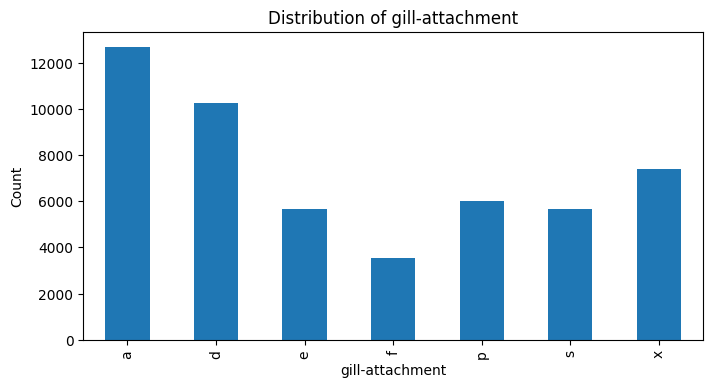

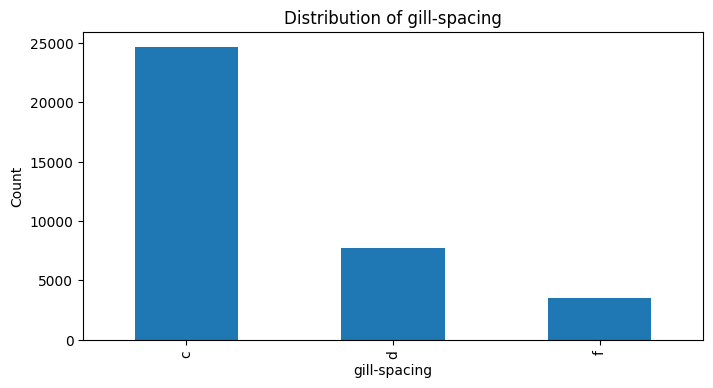

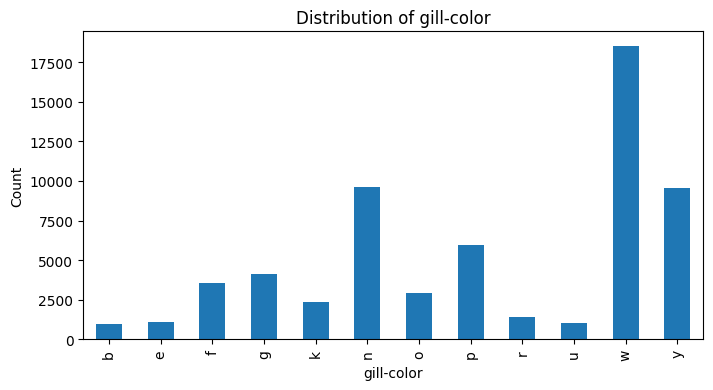

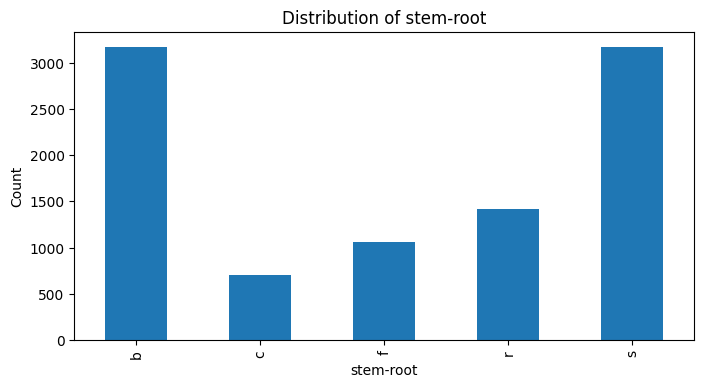

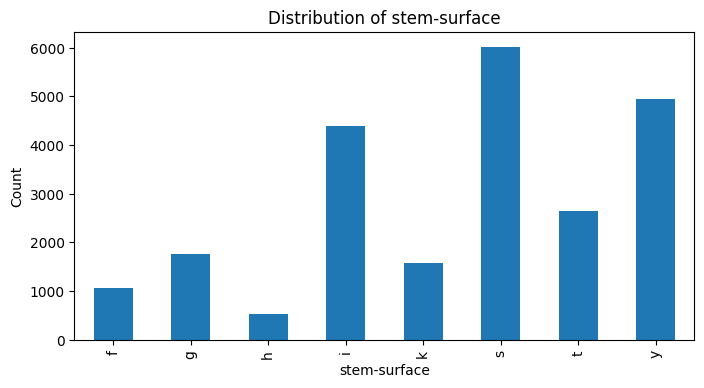

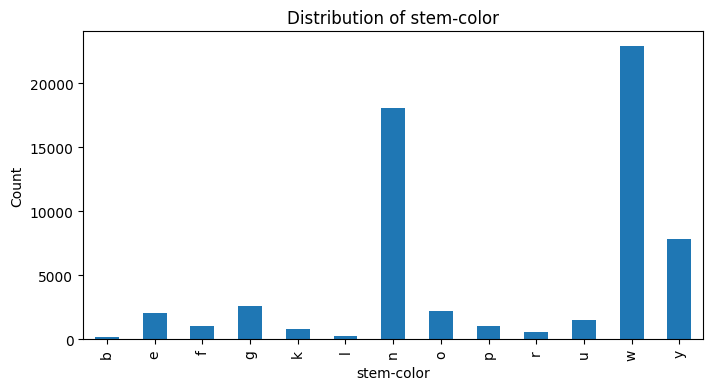

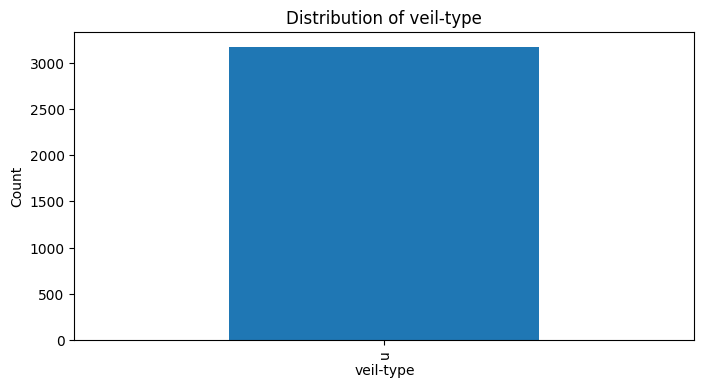

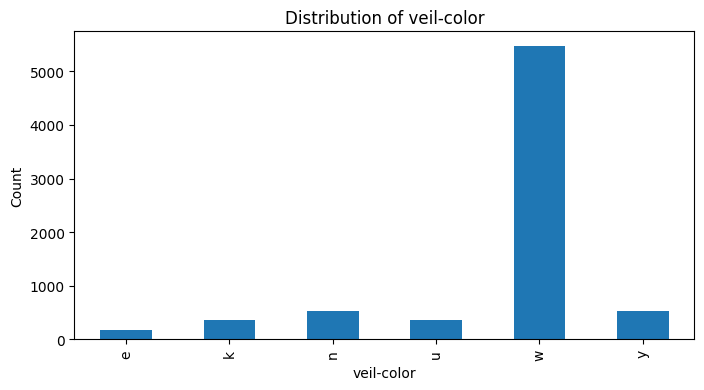

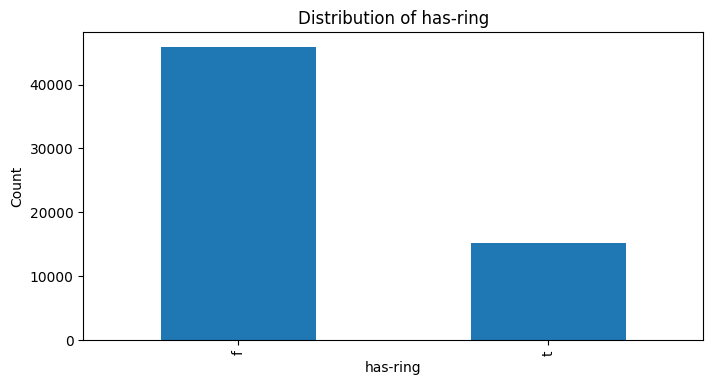

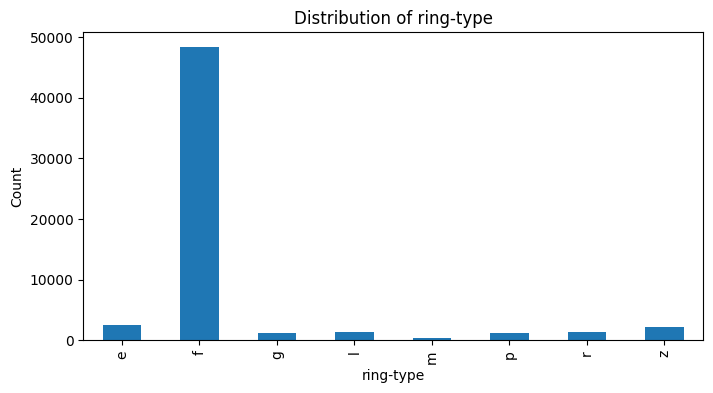

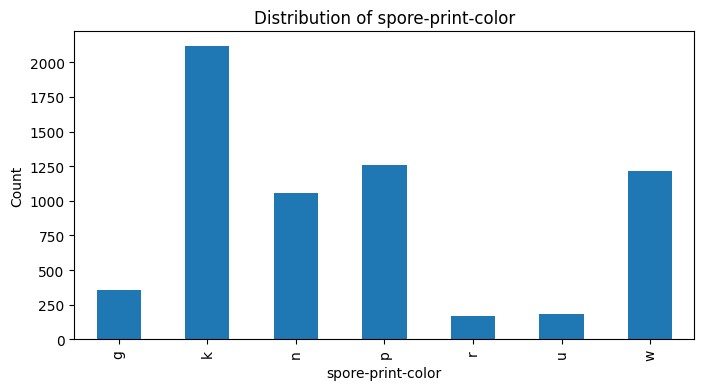

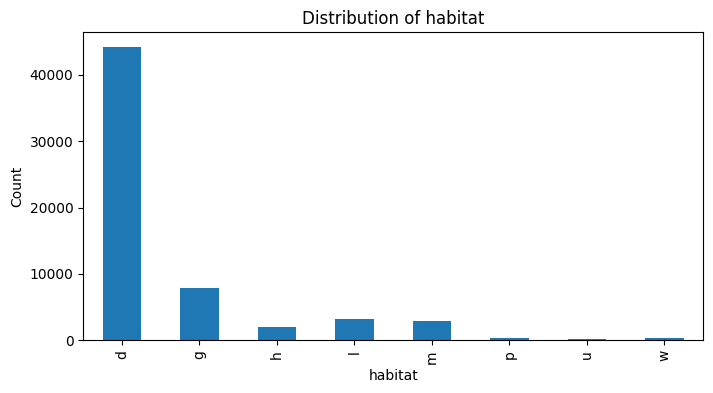

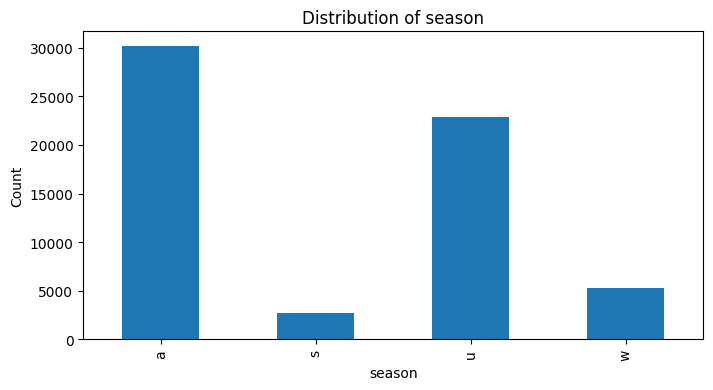

In [22]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))

    df[col].value_counts().sort_index().plot(
        kind='bar',
        xlabel=col,
        ylabel='Count'
    )

    plt.title(f'Distribution of {col}')
    plt.show()

### **Correlation Analysis**



> Correlation matrix



In [23]:
numerical_data = df.select_dtypes(include=['int64', 'float64'])

df_corr = numerical_data.copy()

df_corr['class'] = df['class'].map({
    'e': 0,
    'p': 1
})

correlation_matrix = df_corr.corr()

correlation_matrix

,cap-diameter,stem-height,stem-width,class
cap-diameter,1.000000,0.422560,0.695330,-0.181139
stem-height,0.422560,1.000000,0.436117,-0.121593
stem-width,0.695330,0.436117,1.000000,-0.197368
class,-0.181139,-0.121593,-0.197368,1.000000




> Plotting the heatmap for correlation matrix



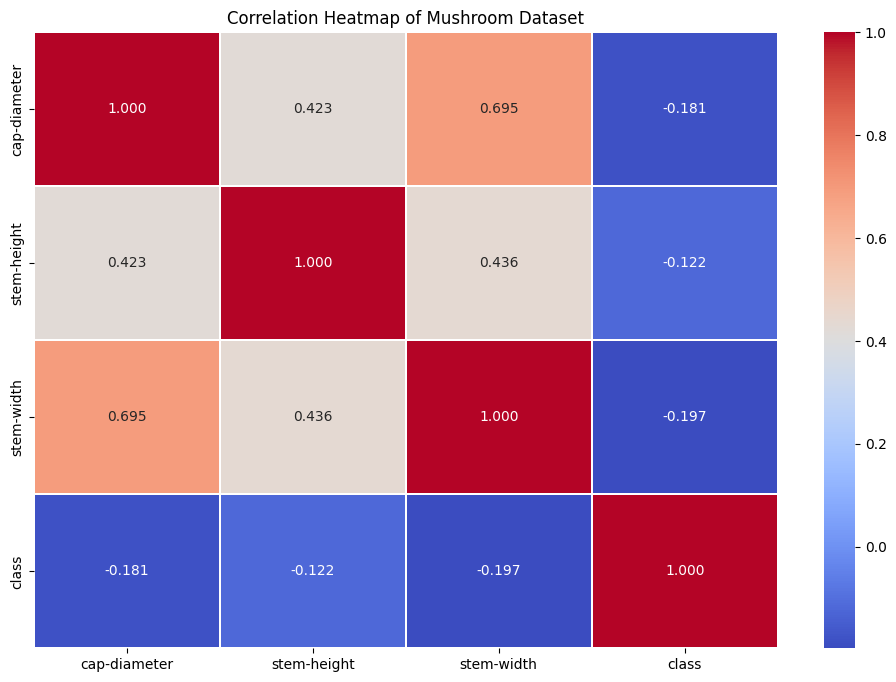

In [24]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.3
)

plt.title('Correlation Heatmap of Mushroom Dataset')
plt.show()



> Correlation plot between numerical features and target



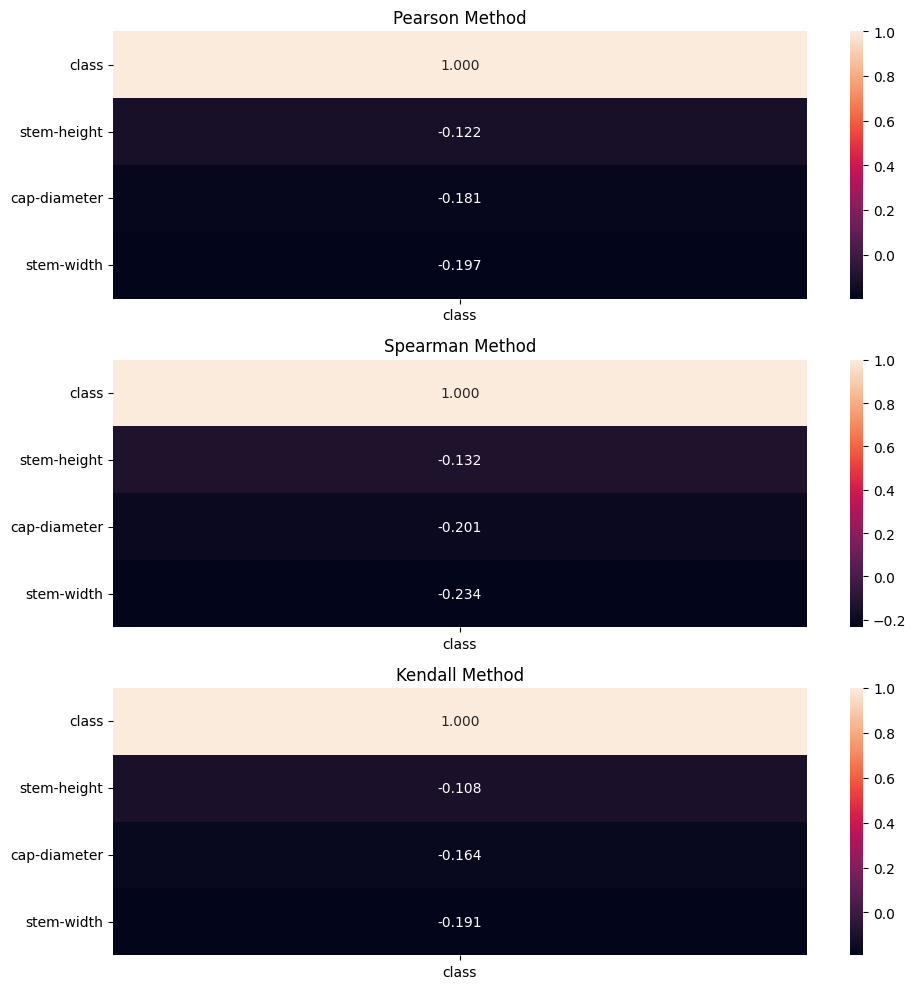

In [25]:
numerical_data = df.select_dtypes(include=['int64', 'float64']).copy()

numerical_data['class'] = df['class'].map({
    'e': 0,
    'p': 1
})

fig, ax = plt.subplots(3, 1, figsize=(10, 10))


corr1 = numerical_data.corr(method='pearson')[['class']].sort_values(
    by='class', ascending=False
)

corr2 = numerical_data.corr(method='spearman')[['class']].sort_values(
    by='class', ascending=False
)

corr3 = numerical_data.corr(method='kendall')[['class']].sort_values(
    by='class', ascending=False
)

ax[0].set_title('Pearson Method')
ax[1].set_title('Spearman Method')
ax[2].set_title('Kendall Method')

sns.heatmap(corr1, ax=ax[0], annot=True, fmt='.3f')
sns.heatmap(corr2, ax=ax[1], annot=True, fmt='.3f')
sns.heatmap(corr3, ax=ax[2], annot=True, fmt='.3f')

plt.tight_layout()
plt.show()

### **Density plot of numerical features**

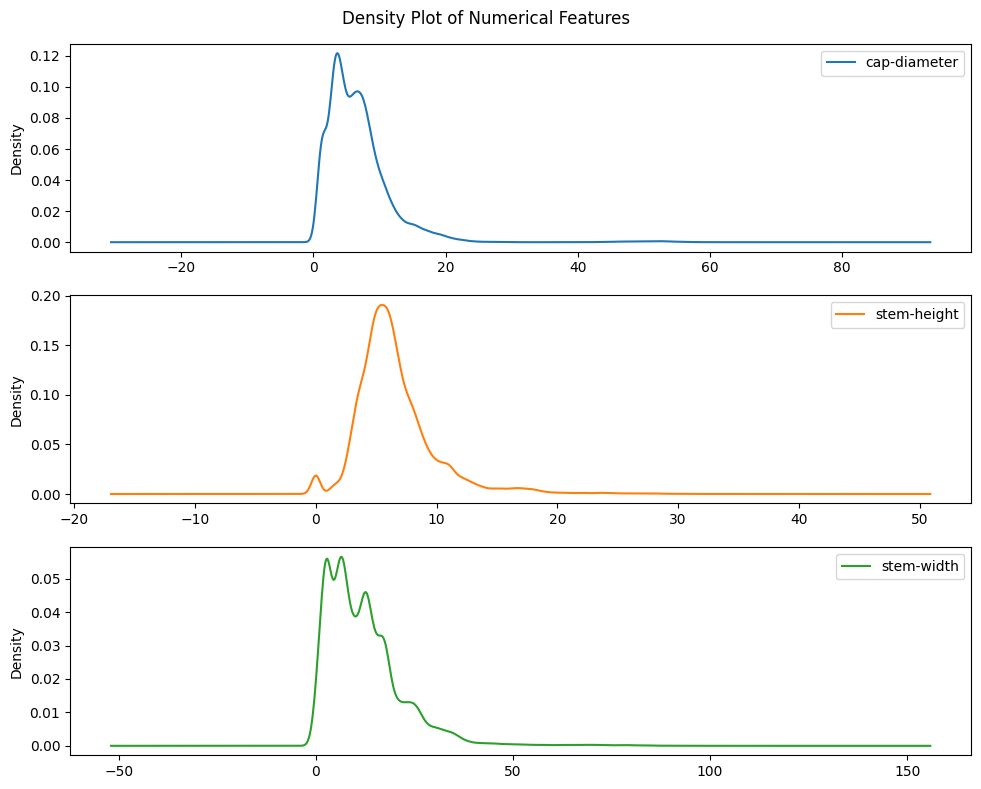

In [26]:
numerical_data = df.select_dtypes(include=['int64', 'float64'])

numerical_data.plot(
    kind='density',
    figsize=(10, 8),
    subplots=True,
    layout=(3, 1),
    title="Density Plot of Numerical Features",
    sharex=False
)

plt.tight_layout()
plt.show()

Density Plot of Numerical Features:

Density plots were used to visualize the distribution of the numerical features in the mushroom dataset. The plots show the distribution and concentration of values for cap diameter, stem height, and stem width. These visualizations help identify the general shape of the distributions and any potential skewness or unusual patterns in the numerical features.



> Conclusion of EDA:

Exploratory Data Analysis was performed using descriptive statistics, variance analysis, skewness analysis, histograms, boxplots, categorical distributions, correlation analysis, and class distribution analysis. The dataset contains both numerical and categorical features, with numerical features having different scales and distributions. Several categorical features showed different distributions across the target classes, indicating potentially useful relationships for classification. These findings help determine the necessary preprocessing steps before training machine learning models.



# **Dataset Pre-processing**

## Faults & Solutions



### **Problem 1: Null / Missing Values**



In [27]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

cap-surface          14120
gill-attachment       9884
gill-spacing         25063
stem-root            51538
stem-surface         38124
veil-type            57892
veil-color           53656
ring-type             2471
spore-print-color    54715
dtype: int64




> Solution




*   Remove columns with more than 80% missing values.
*   Fill the remaining categorical missing values using the mode.



In [28]:
threshold = 0.80

high_missing_cols = df.columns[
    df.isnull().mean() > threshold
].tolist()

print("Columns removed:", high_missing_cols)

df = df.drop(columns=high_missing_cols)

Columns removed: ['stem-root', 'veil-type', 'veil-color', 'spore-print-color']


In [29]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 0


The dataset contained missing values in several categorical features. Some features had an extremely high percentage of missing values.

**Solution:** Features with more than 80% missing values were removed because imputing such a large proportion could introduce unreliable information. The remaining missing categorical values were imputed using the mode. After preprocessing, no missing values remained.

### **Problem 2: Categorical Values**

In [30]:
categorical_cols = df.drop('class', axis=1).select_dtypes(
    include='object'
).columns

print("Categorical features:")
print(categorical_cols.tolist())

Categorical features:
['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-surface', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']




> Solution



In [31]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

The dataset contains categorical variables that cannot be directly processed by most machine learning algorithms.

**Solution:** One-Hot Encoding will be used to convert categorical features into numerical representations. handle_unknown='ignore' will ensure that unseen categories in the test data do not cause errors.

### **Problem 3: Feature Scaling**

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [33]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

The numerical features have different scales, which can affect distance-based algorithms such as KNN.

**Solution:** StandardScaler will be used to standardize the numerical features. Scaling will be performed only using the training data through a preprocessing pipeline to prevent data leakage.

# **Dataset Splitting**

In [34]:
from sklearn.model_selection import train_test_split

# Separate input features and target
X = df.drop('class', axis=1)
y = df['class']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (48855, 16)
Testing set: (12214, 16)


In [35]:
print("Original class distribution:")
print(y.value_counts(normalize=True))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Original class distribution:
class
p    0.554913
e    0.445087
Name: proportion, dtype: float64

Training class distribution:
class
p    0.554907
e    0.445093
Name: proportion, dtype: float64

Testing class distribution:
class
p    0.554937
e    0.445063
Name: proportion, dtype: float64


Dataset Splitting: Since the dataset is a classification problem with an imbalanced class distribution, stratified sampling was used to maintain approximately the same proportion of each class in both datasets. The dataset was divided into 80% training data and 20% testing data. A random_state of 42 was used to make the split reproducible. No separate validation set was used at this stage.
Besdies, An 80/20 split provides sufficient data for model training while keeping an adequate portion of unseen data for evaluating the final model.

# **Model training & testing (Supervised)**



> K-Nearest Neighbors (KNN)



In [36]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN training completed.")

KNN training completed.


K-Nearest Neighbors (KNN) was used as a supervised classification model. The model classifies a new mushroom based on the classes of its nearest neighboring samples. Feature scaling was applied because KNN relies on distance calculations.



> Decision Tree



In [37]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


A Decision Tree classifier was trained to classify mushrooms based on their characteristics. The tree makes decisions by splitting the data according to feature values. A maximum depth was specified to reduce the possibility of overfitting.



> Logistic Regression



In [38]:
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression training completed.")

Logistic Regression training completed.


Logistic Regression was applied as another classification model. It estimates the probability of a sample belonging to each class and selects the most probable class as the prediction.



> Naive Bayes



In [39]:
from sklearn.naive_bayes import GaussianNB

# Transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert to dense if necessary
X_train_processed = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_processed = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

# Train Naive Bayes
nb_model = GaussianNB()

nb_model.fit(X_train_processed, y_train)

nb_pred = nb_model.predict(X_test_processed)

print("Naive Bayes training completed.")

Naive Bayes training completed.


Naive Bayes was applied as a probabilistic classification algorithm. It assumes that the features are conditionally independent given the target class and uses probability estimates to classify the mushrooms.



> Neural Network



In [40]:
X_train_nn = X_train_processed.astype('float64')
X_test_nn = X_test_processed.astype('float64')

In [41]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42
)

nn_model.fit(X_train_nn, y_train)

nn_pred = nn_model.predict(X_test_nn)

print("Neural Network training completed.")

Neural Network training completed.


A Neural Network classifier was implemented using the Multi-Layer Perceptron (MLP) algorithm. The network contains two hidden layers with 100 and 50 neurons. The ReLU activation function and Adam optimizer were used for training. Early stopping was enabled to help prevent overfitting.

In [42]:
predictions = {
    'KNN': knn_pred,
    'Decision Tree': dt_pred,
    'Logistic Regression': lr_pred,
    'Naive Bayes': nb_pred,
    'Neural Network': nn_pred
}

print("All model predictions are ready.")

All model predictions are ready.




> K-Means Clustering (Unsupervised)





*   Preprocessing, K-Means, Cluster




In [43]:
from sklearn.cluster import KMeans

# Use the processed feature data
X_all_processed = preprocessor.fit_transform(X)

X_all_processed = (
    X_all_processed.toarray()
    if hasattr(X_all_processed, 'toarray')
    else X_all_processed
)

# K = 2 because the dataset has 2 actual classes
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_all_processed)

print("K-Means clustering completed.")
print("Clusters:", set(clusters))

K-Means clustering completed.
Clusters: {np.int32(0), np.int32(1)}




*   Visualizing Clusters



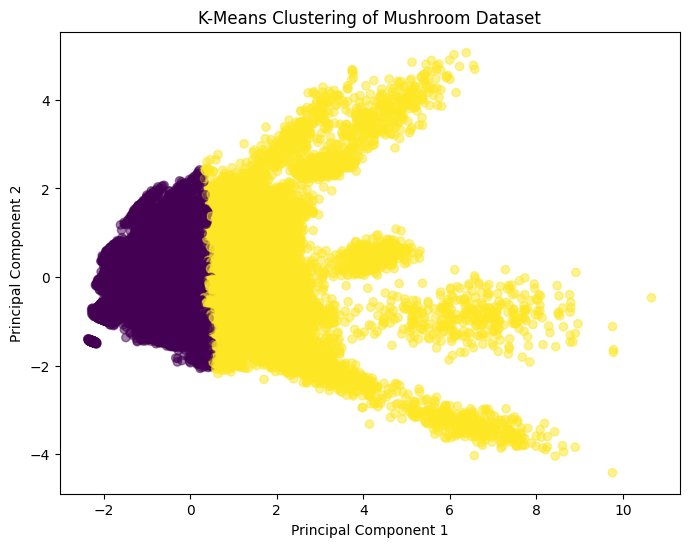

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_all_processed)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.5
)

plt.title("K-Means Clustering of Mushroom Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()



*   Compare with actual class



In [45]:
print(pd.crosstab(
    df['class'],
    clusters,
    rownames=['Actual Class'],
    colnames=['Cluster']
))

Cluster           0      1
Actual Class              
e             16838  10343
p             24637   9251


# **Model Selection/Comparison Analysis**



### **Prediction Accuracy**







In [46]:
from sklearn.metrics import accuracy_score

accuracy_results = {
    'KNN': accuracy_score(y_test, knn_pred),
    'Decision Tree': accuracy_score(y_test, dt_pred),
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Naive Bayes': accuracy_score(y_test, nb_pred),
    'Neural Network': accuracy_score(y_test, nn_pred)
}

print("Accuracy of each model:\n")

for model, accuracy in accuracy_results.items():
    print(f"{model}: {accuracy:.4f}")

Accuracy of each model:

KNN: 1.0000
Decision Tree: 0.9059
Logistic Regression: 0.8139
Naive Bayes: 0.6402
Neural Network: 0.9995




> Bar chart



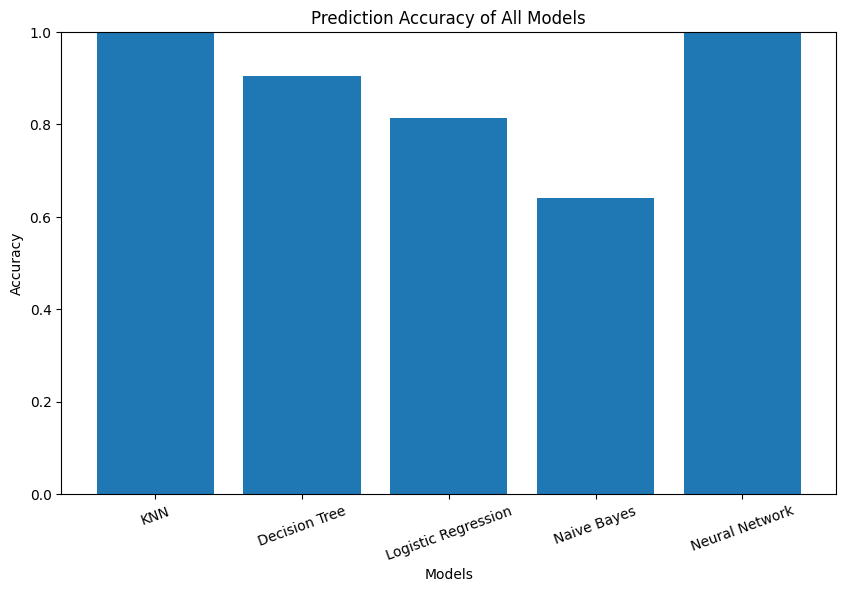

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    accuracy_results.keys(),
    accuracy_results.values()
)

plt.title('Prediction Accuracy of All Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

The prediction accuracy of all five supervised learning models was calculated and compared using a bar chart. The model with the highest accuracy provides the best overall classification performance based on correctly classified test samples.

### **Precision and Recall Comparison**

In [48]:
from sklearn.metrics import precision_score, recall_score

model_predictions = {
    'KNN': knn_pred,
    'Decision Tree': dt_pred,
    'Logistic Regression': lr_pred,
    'Naive Bayes': nb_pred,
    'Neural Network': nn_pred
}

precision_results = {}
recall_results = {}

for model, prediction in model_predictions.items():
    precision_results[model] = precision_score(
        y_test,
        prediction,
        average='weighted',
        zero_division=0
    )

    recall_results[model] = recall_score(
        y_test,
        prediction,
        average='weighted',
        zero_division=0
    )

In [49]:
comparison_df = pd.DataFrame({
    'Model': model_predictions.keys(),
    'Accuracy': accuracy_results.values(),
    'Precision': precision_results.values(),
    'Recall': recall_results.values()
})

comparison_df

,Model,Accuracy,Precision,Recall
0,KNN,1.000000,1.000000,1.000000
1,Decision Tree,0.905928,0.907131,0.905928
2,Logistic Regression,0.813902,0.814558,0.813902
3,Naive Bayes,0.640249,0.760549,0.640249
4,Neural Network,0.999509,0.999509,0.999509




> Bar chart



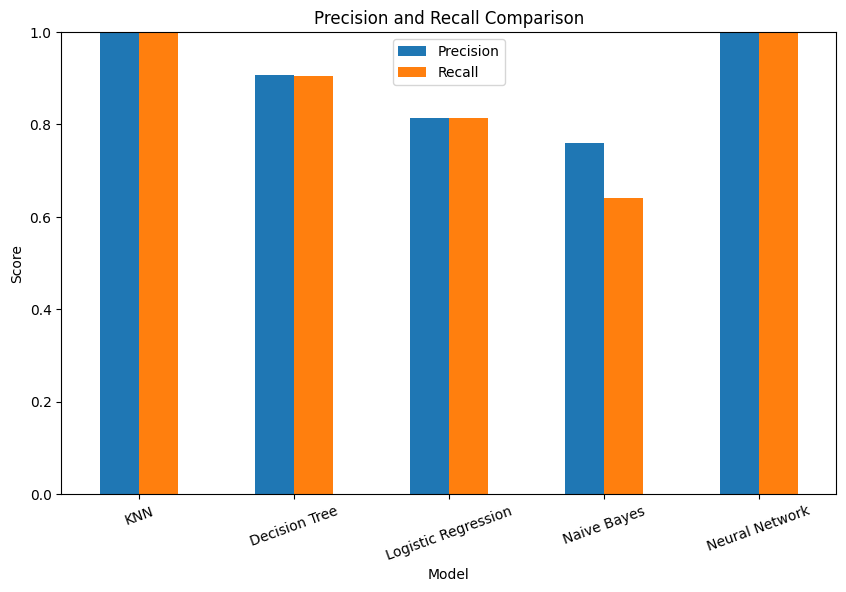

In [50]:
comparison_df.set_index('Model')[[
    'Precision',
    'Recall'
]].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Precision and Recall Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

Precision measures how many of the samples predicted as a particular class were actually correct, while recall measures how many actual samples of a class were correctly identified. The precision and recall values of all models were compared to determine which models provide a better balance between correct predictions and identification of actual classes.

### **Confusion Matrix**

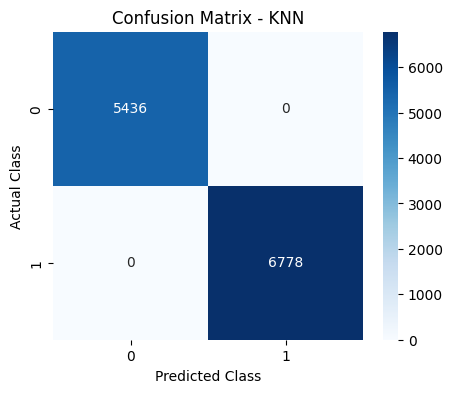

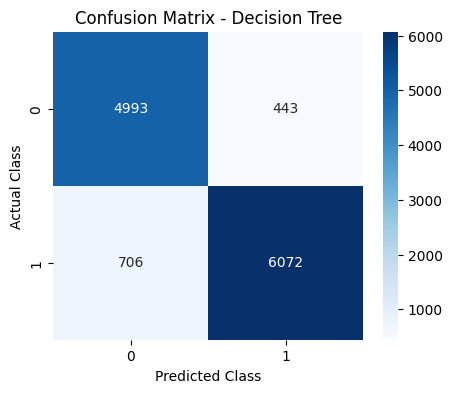

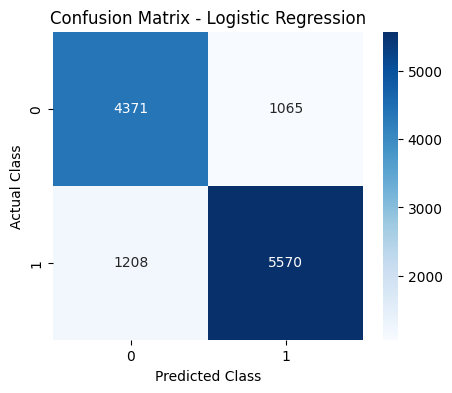

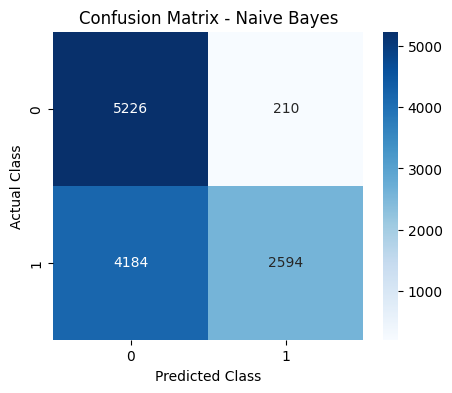

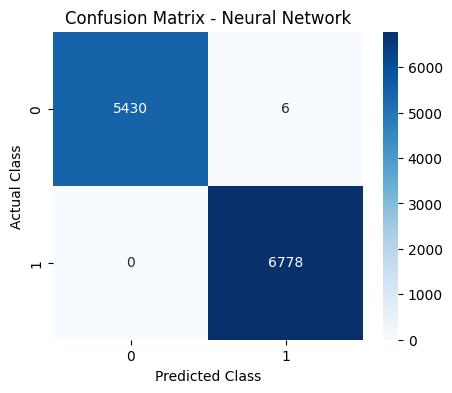

In [51]:
from sklearn.metrics import confusion_matrix

for model, prediction in model_predictions.items():

    cm = confusion_matrix(y_test, prediction)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model}')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')

    plt.show()

Confusion matrices were generated for all classification models. They show the number of correctly and incorrectly classified samples for each class. The diagonal values represent correct predictions, while the off-diagonal values represent misclassifications.

### **Classification Report**

In [52]:
from sklearn.metrics import classification_report

for model, prediction in model_predictions.items():

    print("=" * 60)
    print(model)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            prediction,
            zero_division=0
        )
    )

KNN
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      5436
           p       1.00      1.00      1.00      6778

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg       1.00      1.00      1.00     12214

Decision Tree
              precision    recall  f1-score   support

           e       0.88      0.92      0.90      5436
           p       0.93      0.90      0.91      6778

    accuracy                           0.91     12214
   macro avg       0.90      0.91      0.91     12214
weighted avg       0.91      0.91      0.91     12214

Logistic Regression
              precision    recall  f1-score   support

           e       0.78      0.80      0.79      5436
           p       0.84      0.82      0.83      6778

    accuracy                           0.81     12214
   macro avg       0.81      0.81      0.81     12214
weighted avg       0.81      0.81   

This is for detailed comparison.
This gives:
*   Precision
*   Recall
*   F1-score
*   Support

for each class.

### **ROC Curve and AUC Score**



> Prediction Probabilities



In [53]:
knn_prob = knn_model.predict_proba(X_test)[:, 1]

dt_prob = dt_model.predict_proba(X_test)[:, 1]

lr_prob = lr_model.predict_proba(X_test)[:, 1]

nb_prob = nb_model.predict_proba(X_test_processed)[:, 1]

nn_prob = nn_model.predict_proba(X_test_nn)[:, 1]

In [54]:
print("KNN classes:", knn_model.classes_)
print("Decision Tree classes:", dt_model.classes_)
print("Logistic Regression classes:", lr_model.classes_)
print("Naive Bayes classes:", nb_model.classes_)
print("Neural Network classes:", nn_model.classes_)

KNN classes: ['e' 'p']
Decision Tree classes: ['e' 'p']
Logistic Regression classes: ['e' 'p']
Naive Bayes classes: ['e' 'p']
Neural Network classes: ['e' 'p']




> AUC Score



In [55]:
from sklearn.metrics import roc_auc_score

probabilities = {
    'KNN': knn_prob,
    'Decision Tree': dt_prob,
    'Logistic Regression': lr_prob,
    'Naive Bayes': nb_prob,
    'Neural Network': nn_prob
}

auc_results = {}

for model, probability in probabilities.items():

    auc = roc_auc_score(
        (y_test == 'p').astype(int),
        probability
    )

    auc_results[model] = auc

    print(f"{model}: AUC = {auc:.4f}")

KNN: AUC = 1.0000
Decision Tree: AUC = 0.9666
Logistic Regression: AUC = 0.8831
Naive Bayes: AUC = 0.8054
Neural Network: AUC = 1.0000


The Area Under the Curve (AUC) was calculated for each model. A higher AUC indicates better ability of the model to distinguish between poisonous and edible mushrooms. The ROC curves and AUC scores were used along with accuracy, precision, and recall to compare the overall performance of the models.



> ROC Curves



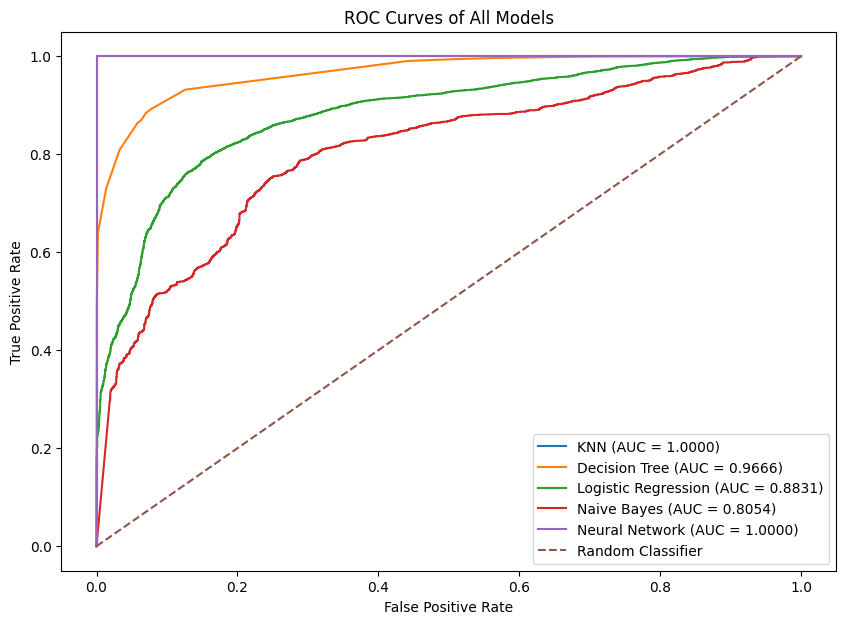

In [56]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for model, probability in probabilities.items():

    fpr, tpr, _ = roc_curve(
        (y_test == 'p').astype(int),
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{model} (AUC = {auc_results[model]:.4f})'
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curves of All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

ROC (Receiver Operating Characteristic) curves were generated for all five supervised classification models. The ROC curve shows the relationship between the True Positive Rate and False Positive Rate at different classification thresholds. In this analysis, the poisonous class (p) was considered the positive class.

### **Final Model Comparison**

In [57]:
final_comparison = pd.DataFrame({
    'Model': list(model_predictions.keys()),
    'Accuracy': [
        accuracy_results[m] for m in model_predictions
    ],
    'Precision': [
        precision_results[m] for m in model_predictions
    ],
    'Recall': [
        recall_results[m] for m in model_predictions
    ],
    'AUC': [
        auc_results[m] for m in model_predictions
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,AUC
0,KNN,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.905928,0.907131,0.905928,0.966642
2,Logistic Regression,0.813902,0.814558,0.813902,0.883101
3,Naive Bayes,0.640249,0.760549,0.640249,0.805378
4,Neural Network,0.999509,0.999509,0.999509,0.999998


### **Overall Comparison**

In [58]:
final_comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,AUC
0,KNN,1.000000,1.000000,1.000000,1.000000
4,Neural Network,0.999509,0.999509,0.999509,0.999998
1,Decision Tree,0.905928,0.907131,0.905928,0.966642
2,Logistic Regression,0.813902,0.814558,0.813902,0.883101
3,Naive Bayes,0.640249,0.760549,0.640249,0.805378


The performance of the five supervised learning models was compared using accuracy, precision, recall, and AUC. KNN achieved the best overall performance, obtaining 100% accuracy, precision, recall, and AUC. The Neural Network performed almost equally well, with 99.95% accuracy, precision, and recall and an AUC of 0.999998. The Decision Tree achieved moderate performance with 90.59% accuracy and an AUC of 0.966642. Logistic Regression showed lower performance, achieving 81.39% accuracy and an AUC of 0.883101. Naive Bayes produced the lowest accuracy (64.02%) and AUC (0.805378) among the five models.

Overall, KNN was the best-performing model for this dataset, while the Neural Network was a very close second. The results indicate that the relationships between the mushroom features and their classes can be captured particularly well by distance-based and neural-network approaches.